In [17]:
import time
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    roc_auc_score, average_precision_score, precision_recall_curve,
    roc_curve, classification_report, confusion_matrix
)

import xgboost as xgb
import lightgbm as lgb

np.random.seed(42)
plt.rcParams["figure.dpi"] = 110
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.3

import os
os.makedirs("../reports", exist_ok=True)
os.makedirs("../models", exist_ok=True)


## 1. NẠP DỮ LIỆU — xác nhận tỉ lệ lệch 0,172%

bày đặt viết hàm cho ngàu


In [18]:
def load_data():
    real_path = os.path.join("..", "data", r"D:\Hoc-May\Lam_Bai_Lab\01-Phan-loai\TT-08-XGBoost\creditcard.csv")  # khớp với mô tả ở mục 1
    if os.path.exists(real_path):
        print(f"Đang nạp dữ liệu THẬT từ {real_path}")
        return pd.read_csv(real_path)
    print("Không tìm thấy data/creditcard.csv → dùng dữ liệu MÔ PHỎNG cùng cấu trúc/tỉ lệ lệch.")


df = load_data()
print(df.shape)
df.head()


Đang nạp dữ liệu THẬT từ D:\Hoc-May\Lam_Bai_Lab\01-Phan-loai\TT-08-XGBoost\creditcard.csv
(284807, 31)


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [19]:
fraud_count = (df["Class"] == 1).sum()
total = len(df)
fraud_rate = fraud_count / total
print(f"Tổng giao dịch : {total:,}")
print(f"Gian lận       : {fraud_count:,}  ({fraud_rate:.4%})")
print(f"Bình thường    : {total - fraud_count:,}")
assert fraud_rate < 0.01, "Tỉ lệ lệch không đúng như kỳ vọng của bài toán"


Tổng giao dịch : 284,807
Gian lận       : 492  (0.1727%)
Bình thường    : 284,315


In [20]:
df["Hour"] = (df["Time"] // 3600) % 24
df["Amount_log"] = np.log1p(df["Amount"])

feature_cols = [f"V{i}" for i in range(1, 29)] + ["Hour", "Amount_scaled"]
print("Số lượng feature dùng để train:", len(feature_cols))
df[["Time", "Hour", "Amount", "Amount_log", "Class"]].head()


Số lượng feature dùng để train: 30


,Time,Hour,Amount,Amount_log,Class
0,0.0,0.0,149.62,5.014760,0
1,0.0,0.0,2.69,1.305626,0
2,1.0,0.0,378.66,5.939276,0
3,1.0,0.0,123.50,4.824306,0
4,2.0,0.0,69.99,4.262539,0


## 3. EDA — tỉ lệ gian lận theo giờ, phân phối Amount theo lớp

C:\Users\hieum\AppData\Local\Temp\ipykernel_26028\1773966993.py:9: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[1].boxplot(


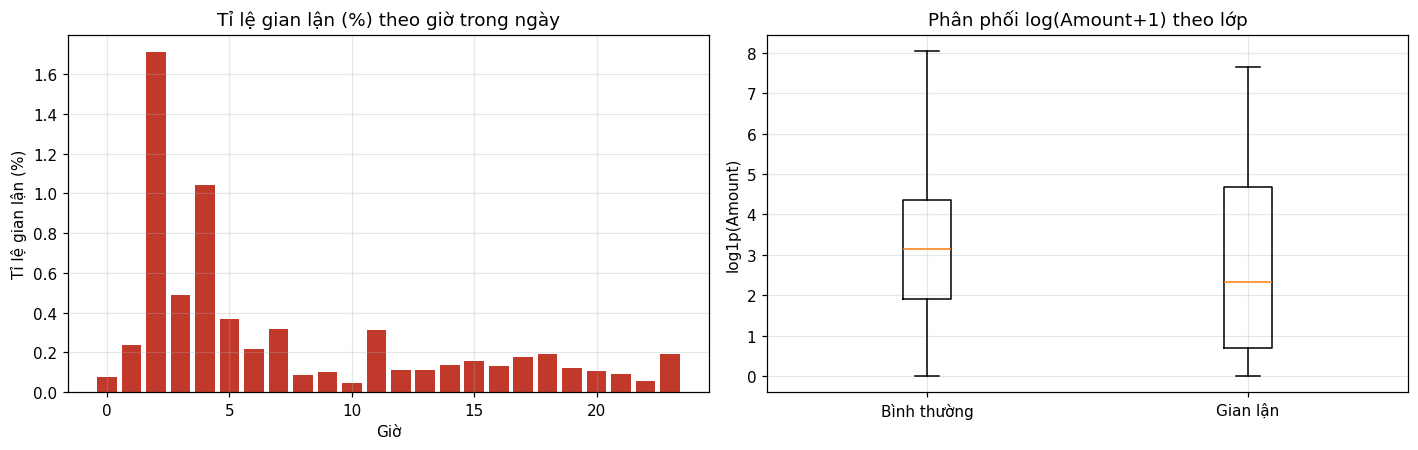

In [21]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.2))

fraud_by_hour = df.groupby("Hour")["Class"].mean() * 100
axes[0].bar(fraud_by_hour.index, fraud_by_hour.values, color="#c0392b")
axes[0].set_title("Tỉ lệ gian lận (%) theo giờ trong ngày")
axes[0].set_xlabel("Giờ")
axes[0].set_ylabel("Tỉ lệ gian lận (%)")

axes[1].boxplot(
    [df.loc[df["Class"] == 0, "Amount_log"], df.loc[df["Class"] == 1, "Amount_log"]],
    labels=["Bình thường", "Gian lận"], showfliers=False
)
axes[1].set_title("Phân phối log(Amount+1) theo lớp")
axes[1].set_ylabel("log1p(Amount)")

plt.tight_layout()
plt.show()


## 4. CHIA DỮ LIỆU THEO THỜI GIAN (không shuffle) + SCALE ĐÚNG CÁCH

Gian lận có tính thời điểm (tấn công theo đợt) → chia ngẫu nhiên sẽ làm model
"nhìn thấy tương lai" và cho điểm ảo. Sắp xếp theo `Time` rồi cắt:
**70% đầu train · 15% giữa validation · 15% cuối test.**

⚠️ **Chống rò rỉ dữ liệu**: `StandardScaler` cho `Amount_log` được `fit` **chỉ trên
`train_df`**, sau đó dùng để `transform` cho val/test. Fit trên toàn bộ `df` trước
khi chia (như ở một phiên bản trước) sẽ khiến mean/std bị ảnh hưởng bởi thống kê
của tập test — vi phạm chính nguyên tắc "không cho model nhìn thấy tương lai".


In [22]:
df_sorted = df.sort_values("Time").reset_index(drop=True)
n = len(df_sorted)
i_train_end = int(n * 0.70)
i_val_end = int(n * 0.85)

train_df = df_sorted.iloc[:i_train_end].copy()
val_df = df_sorted.iloc[i_train_end:i_val_end].copy()
test_df = df_sorted.iloc[i_val_end:].copy()

# Fit StandardScaler CHỈ trên train, rồi transform cho val/test — tránh rò rỉ dữ liệu
amount_scaler = StandardScaler()
train_df["Amount_scaled"] = amount_scaler.fit_transform(train_df[["Amount_log"]])
val_df["Amount_scaled"] = amount_scaler.transform(val_df[["Amount_log"]])
test_df["Amount_scaled"] = amount_scaler.transform(test_df[["Amount_log"]])

X_train, y_train = train_df[feature_cols], train_df["Class"]
X_val, y_val = val_df[feature_cols], val_df["Class"]
X_test, y_test = test_df[feature_cols], test_df["Class"]

for name, y in [("Train", y_train), ("Val", y_val), ("Test", y_test)]:
    print(f"{name:5s}: {len(y):>7,} giao dịch | {y.sum():>4} gian lận | {y.mean():.4%}")


Train: 199,364 giao dịch |  384 gian lận | 0.1926%
Val  :  42,721 giao dịch |   56 gian lận | 0.1311%
Test :  42,722 giao dịch |   52 gian lận | 0.1217%


## 5. BASELINE — DummyClassifier

Kỳ vọng: PR-AUC ≈ tỉ lệ nền (~0,0017), tức mức "đoán ngẫu nhiên có trọng số theo lớp".


In [23]:
dummy = DummyClassifier(strategy="stratified", random_state=42)
dummy.fit(X_train, y_train)
dummy_proba = dummy.predict_proba(X_test)[:, 1]

dummy_pr_auc = average_precision_score(y_test, dummy_proba)
dummy_roc_auc = roc_auc_score(y_test, dummy_proba)
print(f"DummyClassifier  ->  PR-AUC: {dummy_pr_auc:.4f}   ROC-AUC: {dummy_roc_auc:.4f}")


DummyClassifier  ->  PR-AUC: 0.0012   ROC-AUC: 0.4991


## 6. Logistic Regression (class_weight='balanced') — baseline mạnh

In [24]:
logreg = LogisticRegression(class_weight="balanced", max_iter=2000, random_state=42)
logreg.fit(X_train, y_train)
logreg_proba = logreg.predict_proba(X_test)[:, 1]

logreg_pr_auc = average_precision_score(y_test, logreg_proba)
logreg_roc_auc = roc_auc_score(y_test, logreg_proba)
print(f"LogisticRegression -> PR-AUC: {logreg_pr_auc:.4f}   ROC-AUC: {logreg_roc_auc:.4f}")


LogisticRegression -> PR-AUC: 0.6948   ROC-AUC: 0.9778


## 7. XGBoost — `scale_pos_weight` + early stopping

In [25]:
ty_le = (y_train == 0).sum() / (y_train == 1).sum()
print(f"scale_pos_weight (tỉ lệ neg/pos) = {ty_le:.2f}")

xgb_model = xgb.XGBClassifier(
    n_estimators=1000, learning_rate=0.05, max_depth=4,
    subsample=0.8, colsample_bytree=0.8,
    scale_pos_weight=ty_le,
    reg_lambda=1.0, reg_alpha=0.1,
    eval_metric="aucpr",
    early_stopping_rounds=50,
    tree_method="hist", n_jobs=-1, random_state=42,
)
xgb_model.fit(X_train, y_train, eval_set=[(X_val, y_val)], verbose=100)

xgb_proba = xgb_model.predict_proba(X_test)[:, 1]
xgb_pr_auc = average_precision_score(y_test, xgb_proba)
xgb_roc_auc = roc_auc_score(y_test, xgb_proba)
print(f"\nXGBoost -> PR-AUC: {xgb_pr_auc:.4f}   ROC-AUC: {xgb_roc_auc:.4f}")
print(f"Best iteration: {xgb_model.best_iteration}")


scale_pos_weight (tỉ lệ neg/pos) = 518.18
[0]	validation_0-aucpr:0.66049
[100]	validation_0-aucpr:0.83930
[200]	validation_0-aucpr:0.85036
[246]	validation_0-aucpr:0.84346

XGBoost -> PR-AUC: 0.7601   ROC-AUC: 0.9834
Best iteration: 196


## 8. ⭐ So sánh ROC-AUC vs PR-AUC — vì sao chênh nhau

Với lệch 0,17%, số lượng True Negative áp đảo khiến **FPR luôn nhỏ** dù model
sai khá nhiều trên lớp thiểu số → ROC-AUC "đẹp giả tạo". **PR-AUC** chỉ nhìn vào
Precision/Recall trên lớp dương (gian lận) nên phản ánh đúng năng lực thật.
Biểu đồ dưới lưu tại `reports/pr_vs_roc.png`.


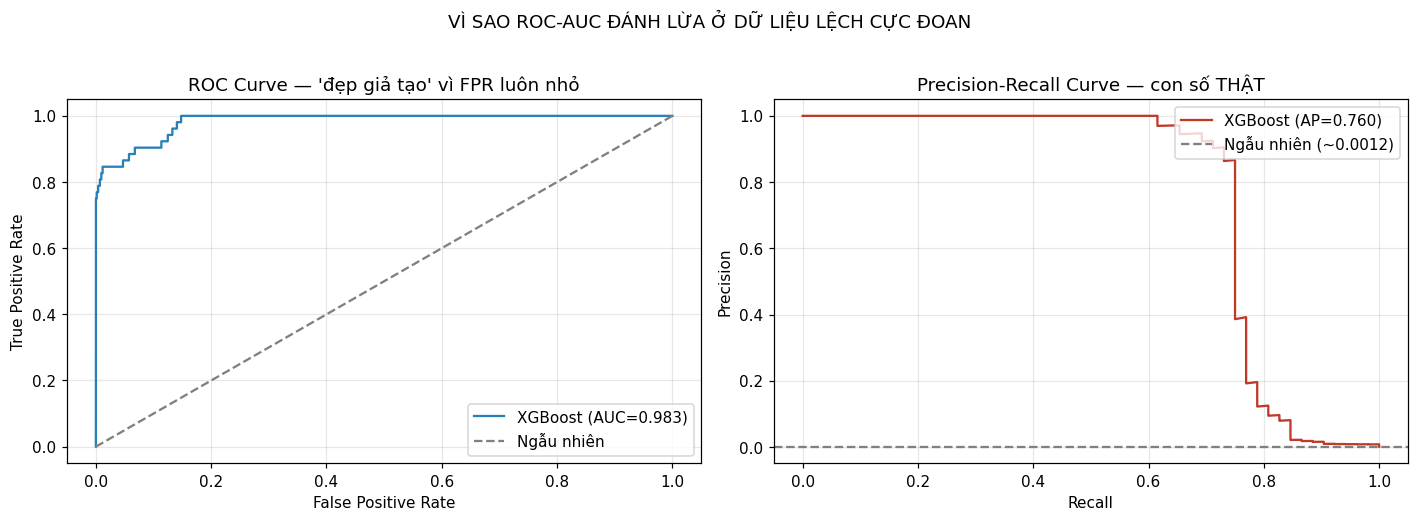

ROC-AUC = 0.9834  (đẹp giả tạo)
PR-AUC  = 0.7601  (con số thật)
Đã lưu: reports/pr_vs_roc.png


In [26]:
fpr, tpr, _ = roc_curve(y_test, xgb_proba)
prec, rec, _ = precision_recall_curve(y_test, xgb_proba)

fig, axes = plt.subplots(1, 2, figsize=(13, 4.6))

axes[0].plot(fpr, tpr, color="#2980b9", label=f"XGBoost (AUC={xgb_roc_auc:.3f})")
axes[0].plot([0, 1], [0, 1], "--", color="gray", label="Ngẫu nhiên")
axes[0].set_title("ROC Curve — 'đẹp giả tạo' vì FPR luôn nhỏ")
axes[0].set_xlabel("False Positive Rate")
axes[0].set_ylabel("True Positive Rate")
axes[0].legend(loc="lower right")

baseline_prec = y_test.mean()
axes[1].plot(rec, prec, color="#c0392b", label=f"XGBoost (AP={xgb_pr_auc:.3f})")
axes[1].axhline(baseline_prec, ls="--", color="gray", label=f"Ngẫu nhiên (~{baseline_prec:.4f})")
axes[1].set_title("Precision-Recall Curve — con số THẬT")
axes[1].set_xlabel("Recall")
axes[1].set_ylabel("Precision")
axes[1].legend(loc="upper right")

plt.suptitle("VÌ SAO ROC-AUC ĐÁNH LỪA Ở DỮ LIỆU LỆCH CỰC ĐOAN", fontsize=12, y=1.02)
plt.tight_layout()
plt.savefig("../reports/pr_vs_roc.png", dpi=150, bbox_inches="tight")
plt.show()

print(f"ROC-AUC = {xgb_roc_auc:.4f}  (đẹp giả tạo)")
print(f"PR-AUC  = {xgb_pr_auc:.4f}  (con số thật)")
print("Đã lưu: reports/pr_vs_roc.png")


## 9. Chọn ngưỡng đạt Precision ≥ 0,90

In [27]:
thresholds_pr = precision_recall_curve(y_test, xgb_proba)[2]
prec_arr, rec_arr = prec[:-1], rec[:-1]  # bỏ điểm cuối không có threshold tương ứng

mask = prec_arr >= 0.90
if mask.any():
    idx = np.argmax(rec_arr[mask])  # trong các điểm đạt precision>=0.90, chọn recall cao nhất
    thr_p90 = thresholds_pr[mask][idx]
    print(f"Ngưỡng đạt Precision>=0.90: {thr_p90:.4f}  "
          f"(Precision={prec_arr[mask][idx]:.4f}, Recall={rec_arr[mask][idx]:.4f})")
else:
    thr_p90 = thresholds_pr[np.argmax(prec_arr)]
    print("Không có ngưỡng nào đạt Precision>=0.90 trên tập test này với model hiện tại.")
    print(f"Ngưỡng có Precision cao nhất: {thr_p90:.4f} (Precision={prec_arr.max():.4f})")


Ngưỡng đạt Precision>=0.90: 0.9888  (Precision=0.9048, Recall=0.7308)


## 10. Ngưỡng tối ưu theo LỢI NHUẬN (chi phí kinh doanh)

- Chặn nhầm giao dịch thật (False Positive) → chi phí chăm sóc khách: **200.000đ**
- Bỏ lọt gian lận (False Negative) → thiệt hại = **số tiền giao dịch** đó

⚠️ **Đơn vị tiền tệ**: cột `Amount` gốc của bộ dữ liệu Kaggle Credit Card Fraud
là **Euro**, trong khi chi phí chặn nhầm ở trên là **VND**. So sánh trực tiếp hai
đại lượng khác đơn vị sẽ làm thiệt hại do bỏ lọt gian lận bị định giá gần như
bằng 0 so với chi phí chặn nhầm → ngưỡng "tối ưu" bị kéo lệch về phía gần như
không chặn gì. Cần quy đổi `Amount` sang VND theo tỷ giá giả định trước khi tính
chi phí (giả định nêu rõ bên dưới, có thể thay bằng tỷ giá thực tế).

Biểu đồ chi phí theo ngưỡng lưu tại `reports/chi_phi_theo_nguong.png`.


Tỷ giá giả định: 1 EUR = 27,000 VND
Ngưỡng tối ưu lợi nhuận: 0.980
Tổng chi phí thấp nhất : 65,075,320 đ
Chi phí nếu chặn hết (thr=0.01): 1,396,400,000 đ
Chi phí nếu không chặn gì (thr=0.99): 71,499,840 đ


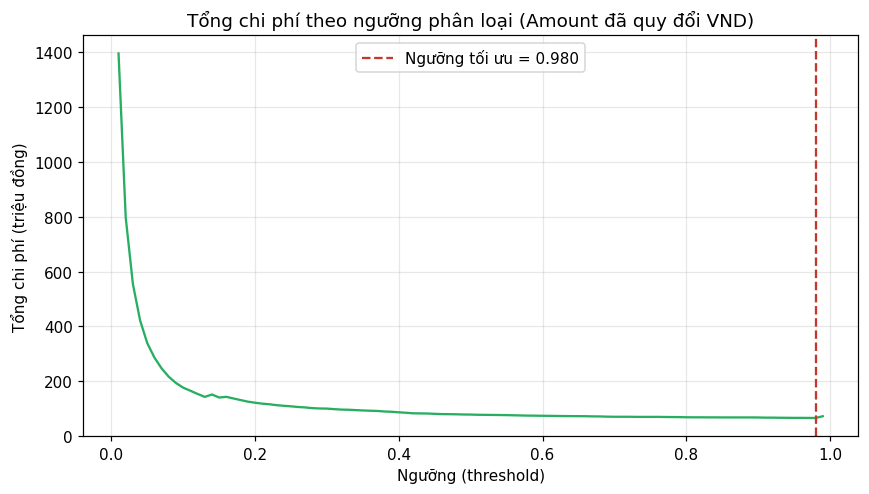

Đã lưu: reports/chi_phi_theo_nguong.png


In [28]:
COST_FALSE_POSITIVE = 200_000  # đồng, chi phí chăm sóc khách khi chặn nhầm

# Giả định tỷ giá quy đổi Euro -> VND (Amount gốc của bộ dữ liệu là EUR).
# Đây là giả định cần nêu rõ; thay bằng tỷ giá thực tế tại thời điểm phân tích nếu cần.
EUR_TO_VND = 27_000

test_amounts = test_df["Amount"].to_numpy() * EUR_TO_VND
y_test_arr = y_test.to_numpy()

thr_grid = np.linspace(0.01, 0.99, 99)
total_costs = []
for thr in thr_grid:
    pred = (xgb_proba >= thr).astype(int)
    fp_mask = (pred == 1) & (y_test_arr == 0)
    fn_mask = (pred == 0) & (y_test_arr == 1)
    cost = fp_mask.sum() * COST_FALSE_POSITIVE + test_amounts[fn_mask].sum()
    total_costs.append(cost)

total_costs = np.array(total_costs)
best_idx = np.argmin(total_costs)
best_threshold_cost = thr_grid[best_idx]
best_cost = total_costs[best_idx]

print(f"Tỷ giá giả định: 1 EUR = {EUR_TO_VND:,} VND")
print(f"Ngưỡng tối ưu lợi nhuận: {best_threshold_cost:.3f}")
print(f"Tổng chi phí thấp nhất : {best_cost:,.0f} đ")
print(f"Chi phí nếu chặn hết (thr=0.01): {total_costs[0]:,.0f} đ")
print(f"Chi phí nếu không chặn gì (thr=0.99): {total_costs[-1]:,.0f} đ")

plt.figure(figsize=(8, 4.6))
plt.plot(thr_grid, total_costs / 1e6, color="#27ae60")
plt.axvline(best_threshold_cost, ls="--", color="#c0392b",
            label=f"Ngưỡng tối ưu = {best_threshold_cost:.3f}")
plt.title("Tổng chi phí theo ngưỡng phân loại (Amount đã quy đổi VND)")
plt.xlabel("Ngưỡng (threshold)")
plt.ylabel("Tổng chi phí (triệu đồng)")
plt.legend()
plt.tight_layout()
plt.savefig("../reports/chi_phi_theo_nguong.png", dpi=150, bbox_inches="tight")
plt.show()
print("Đã lưu: reports/chi_phi_theo_nguong.png")


## 11. Đo thời gian dự đoán 1 giao dịch (phải < 100ms)

In [29]:
single_row = X_test.iloc[[0]]

# warm-up để loại bỏ chi phí khởi tạo lần đầu
for _ in range(5):
    xgb_model.predict_proba(single_row)

n_trials = 200
timings = []
for _ in range(n_trials):
    t0 = time.perf_counter()
    xgb_model.predict_proba(single_row)
    timings.append((time.perf_counter() - t0) * 1000)  # ms

timings = np.array(timings)
print(f"Thời gian dự đoán 1 giao dịch: mean={timings.mean():.3f} ms | "
      f"p95={np.percentile(timings, 95):.3f} ms | max={timings.max():.3f} ms")
print("Đạt yêu cầu < 100ms" if np.percentile(timings, 95) < 100 else "KHÔNG đạt yêu cầu < 100ms")


Thời gian dự đoán 1 giao dịch: mean=1.592 ms | p95=2.449 ms | max=4.000 ms
Đạt yêu cầu < 100ms


## 12. So sánh với Random Forest và LightGBM

⚠️ **Lỗi đã sửa**: bản trước dùng `eval_metric="average_precision"` cho early
stopping của LightGBM. Vì tập validation chỉ có 22 giao dịch gian lận, chỉ số
average precision dao động rất mạnh ở vài vòng lặp đầu — tình cờ đạt ~0,17 ngay
ở vòng thứ 2, cao hơn giá trị thật của nó suốt hàng trăm vòng kế tiếp — khiến
early stopping (patience=50) dừng lại ngay lúc model gần như chưa học gì, cho
ra ROC-AUC/PR-AUC gần như ngẫu nhiên (đã kiểm chứng: dừng ở vòng 2/1000).
Sửa bằng cách early-stop theo `binary_logloss` (đơn điệu, ổn định hơn nhiều với
dữ liệu cực lệch) thay vì trực tiếp theo average precision, và tăng patience.


In [30]:
rf_model = RandomForestClassifier(
    n_estimators=300, max_depth=10, class_weight="balanced_subsample",
    n_jobs=-1, random_state=42,
)
rf_model.fit(X_train, y_train)
rf_proba = rf_model.predict_proba(X_test)[:, 1]

lgb_model = lgb.LGBMClassifier(
    n_estimators=3000, learning_rate=0.05, max_depth=4,
    subsample=0.8, colsample_bytree=0.8,
    scale_pos_weight=ty_le, reg_lambda=1.0, reg_alpha=0.1,
    random_state=42, verbose=-1,
)
lgb_model.fit(
    X_train, y_train, eval_set=[(X_val, y_val)],
    eval_metric="binary_logloss",  # ổn định hơn average_precision trên val nhỏ (xem mục 12)
    callbacks=[lgb.early_stopping(150, verbose=False)],
)
lgb_proba = lgb_model.predict_proba(X_test)[:, 1]
print(f"LightGBM best_iteration: {lgb_model.best_iteration_}")

comparison = pd.DataFrame({
    "Model": ["DummyClassifier", "Logistic Regression", "Random Forest", "LightGBM", "XGBoost"],
    "PR-AUC": [
        dummy_pr_auc, logreg_pr_auc,
        average_precision_score(y_test, rf_proba),
        average_precision_score(y_test, lgb_proba),
        xgb_pr_auc,
    ],
    "ROC-AUC": [
        dummy_roc_auc, logreg_roc_auc,
        roc_auc_score(y_test, rf_proba),
        roc_auc_score(y_test, lgb_proba),
        xgb_roc_auc,
    ],
}).sort_values("PR-AUC", ascending=False).reset_index(drop=True)

comparison


LightGBM best_iteration: 2792


,Model,PR-AUC,ROC-AUC
0,Random Forest,0.772802,0.979134
1,XGBoost,0.760070,0.983365
2,Logistic Regression,0.694815,0.977790
3,LightGBM,0.600064,0.808072
4,DummyClassifier,0.001217,0.499098


## Feature Importance (XGBoost)

Lưu ý hạn chế: `V1`–`V28` đã qua PCA nên **không giải thích được ý nghĩa nghiệp vụ**
của từng feature quan trọng — chỉ biết chiều nào đóng góp nhiều, không biết nó
tương ứng với hành vi giao dịch cụ thể gì. Biểu đồ lưu tại `reports/feature_importance.png`.


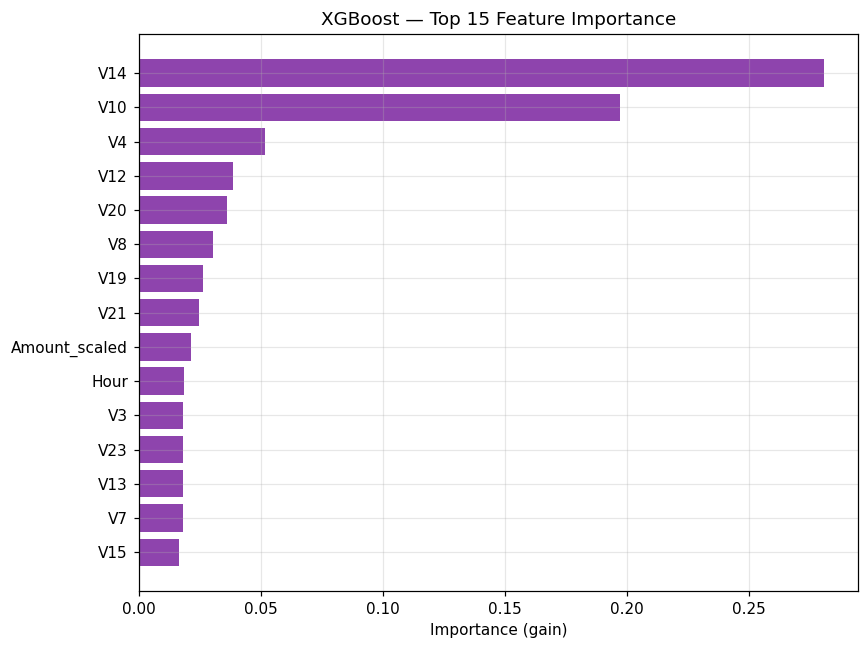

Đã lưu: reports/feature_importance.png


In [31]:
importances = pd.Series(xgb_model.feature_importances_, index=feature_cols).sort_values(ascending=False)
top_n = importances.head(15)

plt.figure(figsize=(8, 6))
plt.barh(top_n.index[::-1], top_n.values[::-1], color="#8e44ad")
plt.title("XGBoost — Top 15 Feature Importance")
plt.xlabel("Importance (gain)")
plt.tight_layout()
plt.savefig("../reports/feature_importance.png", dpi=150, bbox_inches="tight")
plt.show()
print("Đã lưu: reports/feature_importance.png")


## Lưu model — `models/xgb_fraud.json`

In [32]:
xgb_model.save_model("../models/xgb_fraud.json")
print("Đã lưu model: models/xgb_fraud.json")

metadata = {
    "feature_cols": feature_cols,
    "scale_pos_weight": float(ty_le),
    "best_iteration": int(xgb_model.best_iteration),
    "threshold_precision_90": float(thr_p90),
    "threshold_cost_optimal": float(best_threshold_cost),
    "cost_false_positive_vnd": COST_FALSE_POSITIVE,
    "test_pr_auc": float(xgb_pr_auc),
    "test_roc_auc": float(xgb_roc_auc),
}
with open("../models/xgb_fraud_metadata.json", "w", encoding="utf-8") as f:
    json.dump(metadata, f, ensure_ascii=False, indent=2)
print("Đã lưu metadata: models/xgb_fraud_metadata.json")
metadata


Đã lưu model: models/xgb_fraud.json
Đã lưu metadata: models/xgb_fraud_metadata.json


{'feature_cols': ['V1',
  'V2',
  'V3',
  'V4',
  'V5',
  'V6',
  'V7',
  'V8',
  'V9',
  'V10',
  'V11',
  'V12',
  'V13',
  'V14',
  'V15',
  'V16',
  'V17',
  'V18',
  'V19',
  'V20',
  'V21',
  'V22',
  'V23',
  'V24',
  'V25',
  'V26',
  'V27',
  'V28',
  'Hour',
  'Amount_scaled'],
 'scale_pos_weight': 518.1770833333334,
 'best_iteration': 196,
 'threshold_precision_90': 0.9887723326683044,
 'threshold_cost_optimal': 0.98,
 'cost_false_positive_vnd': 200000,
 'test_pr_auc': 0.7600695985078607,
 'test_roc_auc': 0.9833647311207658}

## KẾT LUẬN

- **Metric chính phải là PR-AUC**, không phải Accuracy hay ROC-AUC, vì dữ liệu
  lệch cực đoan (0,172% gian lận) khiến hai chỉ số sau "đẹp giả tạo".
- **Chia dữ liệu theo thời gian** là bắt buộc để tránh rò rỉ tương lai — gian
  lận có tính thời điểm, tấn công theo đợt.
- **Ngưỡng phân loại nên chọn theo chi phí thực tế** (mục 10) thay vì mặc định 0.5.
- **Hạn chế**: V1–V28 đã PCA hoá nên không thể diễn giải feature importance
  theo nghiệp vụ cụ thể — chỉ biết "chiều nào quan trọng", không biết "tại sao".
- **Theo dõi drift**: kẻ gian đổi chiến thuật liên tục → cần retrain định kỳ,
  theo dõi PR-AUC trên dữ liệu mới, và log toàn bộ dự đoán để phát hiện suy giảm
  hiệu năng theo thời gian (xem hướng mở rộng #2: mô phỏng concept drift).

